## ___Refactors___
-------------------

In [1]:
# Goal => get rid of all the superficial dependencies and make the code base bare bones

In [1]:
!python --version

Python 3.13.9


The system cannot find the path specified.


In [38]:
import json
import os
from PIL import Image

# why do these cunts love overcomplicating shit??
from hydra import compose, initialize
from hydra.utils import instantiate
from omegaconf import OmegaConf

import torch
import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt
from matplotlib.pyplot import Axes

In [42]:
os.listdir(r"./configs/sam2.1/")

['sam2.1_hiera_l.json', 'sam2.1_hiera_l.yaml']

In [9]:
hydra_overrides_extra = [
            # dynamically fall back to multi-mask if the single mask is not stable
            "++sam21_hiera_l.sam_mask_decoder_extra_args.dynamic_multimask_via_stability=true",
            "++sam21_hiera_l.sam_mask_decoder_extra_args.dynamic_multimask_stability_delta=0.05",
            "++sam21_hiera_l.sam_mask_decoder_extra_args.dynamic_multimask_stability_thresh=0.98",
        ]

In [20]:
# convert all the .yaml configs to .json
for conf in os.listdir(r"./configs/sam2.1/"):
    if conf.endswith(r".yaml"):
        with initialize(config_path=r"./configs/sam2.1/", job_name="_", version_base=None):
            config = compose(config_name=f"{conf}", overrides=hydra_overrides_extra)
            OmegaConf.resolve(config)
            with open(f"configs/sam2.1/{conf.replace('yaml', 'json')}", mode="w") as fp:
                json.dump(obj=OmegaConf.to_object(config), fp=fp, indent=3)

In [43]:
# do the same for sam2 as well
# for conf in os.listdir(r"./configs/sam2/"):
#     if conf.endswith(r".yaml"):
#         with initialize(config_path=r"./configs/sam2/", job_name="_", version_base=None):
#             config = compose(config_name=f"{conf}", overrides=hydra_overrides_extra)
#             OmegaConf.resolve(config)
#             with open(f"configs/sam2/{conf.replace('yaml', 'json')}", mode="w") as fp:
#                 json.dump(obj=OmegaConf.to_object(config), fp=fp, indent=3)

In [23]:
config["sam21_hiera_l"]["sam_mask_decoder_extra_args"]

{'dynamic_multimask_via_stability': True, 'dynamic_multimask_stability_delta': 0.05, 'dynamic_multimask_stability_thresh': 0.98}

In [28]:
config.sam21_hiera_l

{'_target_': 'sam2.modeling.sam2_base.SAM2Base', 'image_encoder': {'_target_': 'sam2.modeling.backbones.image_encoder.ImageEncoder', 'scalp': 1, 'trunk': {'_target_': 'sam2.modeling.backbones.hieradet.Hiera', 'embed_dim': 144, 'num_heads': 2, 'stages': [2, 6, 36, 4], 'global_att_blocks': [23, 33, 43], 'window_pos_embed_bkg_spatial_size': [7, 7], 'window_spec': [8, 4, 16, 8]}, 'neck': {'_target_': 'sam2.modeling.backbones.image_encoder.FpnNeck', 'position_encoding': {'_target_': 'sam2.modeling.position_encoding.PositionEmbeddingSine', 'num_pos_feats': 256, 'normalize': True, 'scale': None, 'temperature': 10000}, 'd_model': 256, 'backbone_channel_list': [1152, 576, 288, 144], 'fpn_top_down_levels': [2, 3], 'fpn_interp_model': 'nearest'}}, 'memory_attention': {'_target_': 'sam2.modeling.memory_attention.MemoryAttention', 'd_model': 256, 'pos_enc_at_input': True, 'layer': {'_target_': 'sam2.modeling.memory_attention.MemoryAttentionLayer', 'activation': 'relu', 'dim_feedforward': 2048, 'dro

In [22]:
# we should now be able to use the sam21_hiera_l using simple json configs without all that meta crap!

In [29]:
# do a dummy instantiation without hydra and OmegaConf

from modeling.sam2_base import SAM2Base

In [5]:
with open(r"./configs/sam2.1/sam2.1_hiera_l.json", mode="r") as fp:
    sam_21_hiera_l_conf = json.load(fp=fp)

In [15]:
sam_21_hiera_l_conf["sam21_hiera_l"]#["memory_encoder"]

{'_target_': 'sam2.modeling.sam2_base.SAM2Base',
 'image_encoder': {'_target_': 'sam2.modeling.backbones.image_encoder.ImageEncoder',
  'scalp': 1,
  'trunk': {'_target_': 'sam2.modeling.backbones.hieradet.Hiera',
   'embed_dim': 144,
   'num_heads': 2,
   'stages': [2, 6, 36, 4],
   'global_att_blocks': [23, 33, 43],
   'window_pos_embed_bkg_spatial_size': [7, 7],
   'window_spec': [8, 4, 16, 8]},
  'neck': {'_target_': 'sam2.modeling.backbones.image_encoder.FpnNeck',
   'position_encoding': {'_target_': 'sam2.modeling.position_encoding.PositionEmbeddingSine',
    'num_pos_feats': 256,
    'normalize': True,
    'scale': None,
    'temperature': 10000},
   'd_model': 256,
   'backbone_channel_list': [1152, 576, 288, 144],
   'fpn_top_down_levels': [2, 3],
   'fpn_interp_model': 'nearest'}},
 'memory_attention': {'_target_': 'sam2.modeling.memory_attention.MemoryAttention',
  'd_model': 256,
  'pos_enc_at_input': True,
  'layer': {'_target_': 'sam2.modeling.memory_attention.MemoryAtten

In [16]:
# _target_ is the class name, and the rest of the key value pairs within that curly braces are arguments to instantiate an object of that class
# e.g. {'_target_': 'sam2.modeling.memory_encoder.CXBlock', 'dim': 256, 'kernel_size': 7, 'padding': 3, 'layer_scale_init_value': 1e-06, 'use_dwconv': True} means

from modeling.memory_encoder import CXBlock
CXBlock(**{'dim': 256, 'kernel_size': 7, 'padding': 3, 'layer_scale_init_value': 1e-06, 'use_dwconv': True}) # that's how it's done :)

CXBlock(
  (dwconv): Conv2d(256, 256, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=256)
  (norm): LayerNorm2d()
  (pwconv1): Linear(in_features=256, out_features=1024, bias=True)
  (act): GELU(approximate='none')
  (pwconv2): Linear(in_features=1024, out_features=256, bias=True)
  (drop_path): Identity()
)

## ___Trail Run___
--------------------

In [44]:
# do a trial run

from build_sam import build_sam21_hiera_l
from sam2_image_predictor import SAM2ImagePredictor
from automatic_mask_generator import SAM2AutomaticMaskGenerator

In [47]:
sam21_hiera_l = build_sam21_hiera_l(checkpoint_path=r"../../bin/sam2.1_hiera_large.pt", device="cpu", mode="eval") # cool :)
predictor = SAM2ImagePredictor(sam21_hiera_l)

In [26]:
image = np.array(Image.open(r"../../images/Swift-GLX.jpg"))

In [27]:
with torch.inference_mode():
    predictor.set_image(image)
    masks, *_ = predictor.predict() 

In [31]:
masks.shape # (number of masks, H, W)

(3, 1536, 2048)

In [39]:
def plot_segmentations(ax: Axes, masks: NDArray[np.integer], height: int, width: int, alpha: float=0.35) -> Axes:
    """
    """

    rgba = np.ones((height, width, 4))
    for mask in masks:
        rgba[:, :, 3] = 0 # set all the alpha channel values to 0
        # use the boolean mask to cherry pick the elements where the mask applies
        rgba[mask.astype(np.bool), :] = np.array([*np.random.random(3), alpha]) # and update the colour (RGB) values with the specified alpha value
        ax.imshow(rgba)
    return ax

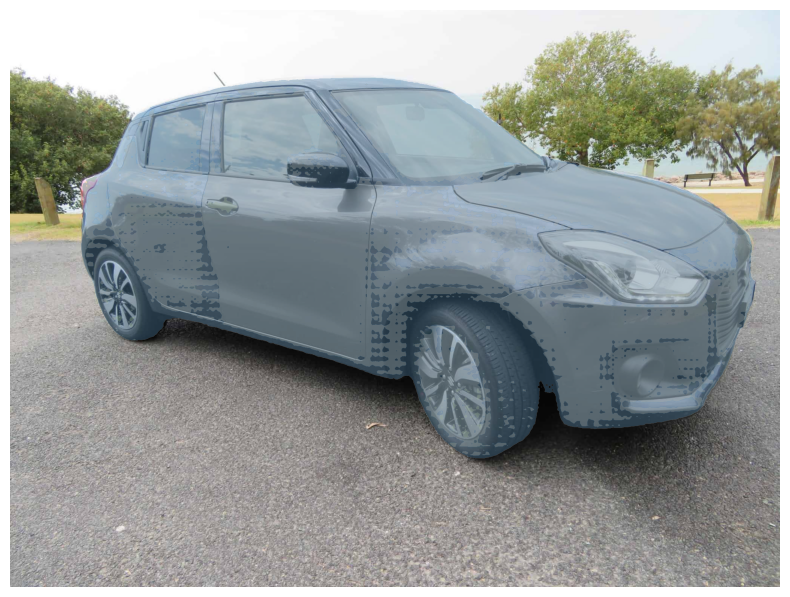

In [40]:
# that's disappointing :/
fig, axes = plt.subplots()
fig.set_size_inches(10, 7.5)
axes.set_axis_off()
axes.imshow(image)
plot_segmentations(ax=axes, masks=masks, height=1536, width=2048)
plt.show()

In [ ]:
amg = SAM2AutomaticMaskGenerator(
    model=sam21_hiera_l,
    points_per_side=64,
    points_per_batch=128,
    pred_iou_thresh=0.7,
    stability_score_thresh=0.92,
    stability_score_offset=0.7,
    crop_n_layers=1,
    box_nms_thresh=0.7,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=25.0,
    use_m2m=True
)
masks = amg.generate(image)

C:\Users\90963425\OneDrive - Western Sydney University\PhD\code\models\sam2\sam2\sam2_image_predictor.py:351: UserWarning: No module named 'sam2'

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  masks = self._transforms.postprocess_masks(low_res_masks, self._orig_hw[img_idx])


In [ ]:
fig, axes = plt.subplots()
fig.set_size_inches(10, 7.5)
axes.set_axis_off()
axes.imshow(image)
plot_segmentations(ax=axes, masks=masks, height=1536, width=2048)
plt.show()